In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df1 = pd.read_csv('../ncbi_562_data.csv')
df2 = pd.read_csv('../ncbi_590_data.csv')



C:\Users\bryan_crnqtx7\AppData\Local\Temp\ipykernel_21284\1780632659.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../ncbi_590_data.csv')


In [2]:
df1 = df1[df1['is_usa_based'] == 1]
df1['collection_year'] = pd.to_numeric(df1['collection_year'], errors='coerce')
df1 = df1[df1['collection_year'] >= 1971]
df1 = df1[df1['month'].notna()]
df1['collection_year'] = df1['collection_year'].astype(str)
df1['collection_year'] = df1['collection_year'].str[:4]
df1['month'] = df1['month'].astype(int)
df1['month'] = df1['month'].apply(lambda x: f"{x:02d}")
df1['year_and_month'] = df1['collection_year'] + '-' + df1['month']

df2 = df2[df2['is_usa_based'] == 1]
df2['collection_year'] = pd.to_numeric(df2['collection_year'], errors='coerce')
df2 = df2[df2['collection_year'] >= 1971]
df2 = df2[df2['month'].notna()]
df2['collection_year'] = df2['collection_year'].astype(str)
df2['collection_year'] = df2['collection_year'].str[:4]
df2['month'] = df2['month'].astype(int)
df2['month'] = df2['month'].apply(lambda x: f"{x:02d}")
df2['year_and_month'] = df2['collection_year'] + '-' + df2['month']

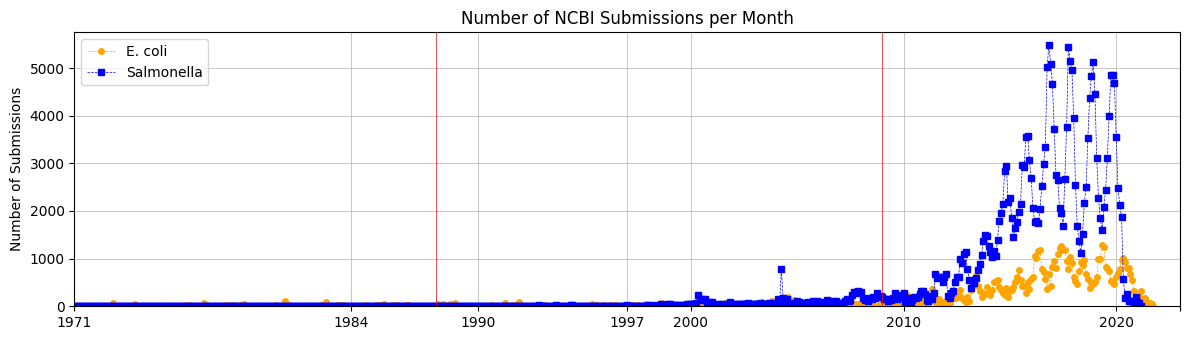

In [4]:
#make a line plot of the value_counts of year_and_month. Put both dataframes on the same plot
year_month_counts1 = df1['year_and_month'].value_counts().sort_index()
#add counts of 0 for each month of each year where there is no count
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts1.index:
            year_month_counts1[year_month] = 0
year_month_counts1 = year_month_counts1.sort_index()
year_month_counts2 = df2['year_and_month'].value_counts().sort_index()
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts2.index:
            year_month_counts2[year_month] = 0
year_month_counts2 = year_month_counts2.sort_index()
plt.figure(figsize=(12, 3.5))
#use smaller markers

year_month_counts1.plot(kind='line', marker='o', label='E. coli', color='orange', linestyle='--', markersize=4,linewidth=0.5)
year_month_counts2.plot(kind='line', marker='s', label='Salmonella', color='blue', linestyle='--', markersize=4, linewidth=0.5)
plt.title('Number of NCBI Submissions per Month')
plt.ylabel('Number of Submissions')
plt.xlabel('')
#plt.xticks(ticks=range(0, len(year_month_counts1), 12), labels=year_month_counts1.index[::12].str.replace('-01', ''), rotation=45)
plt.xlim(left='1971', right='2021')
plt.ylim(bottom=0)
plt.xticks(ticks=[0, 12*13, 12*19, 12*26, 12*29, 12*39, 12*49, 12*52], labels=['1971', '1984', '1990', '1997', '2000', '2010', '2020', ''])
plt.axvline(x=12*38, color='red', linestyle='-', linewidth=0.5)
plt.axvline(x=12*17, color='red', linestyle='-', linewidth=0.5)
plt.legend()
plt.grid(linewidth=0.5)
plt.tight_layout()
plt.savefig('../outputs/from_1971_ncbi_526_590.tiff', dpi=400)
plt.show()

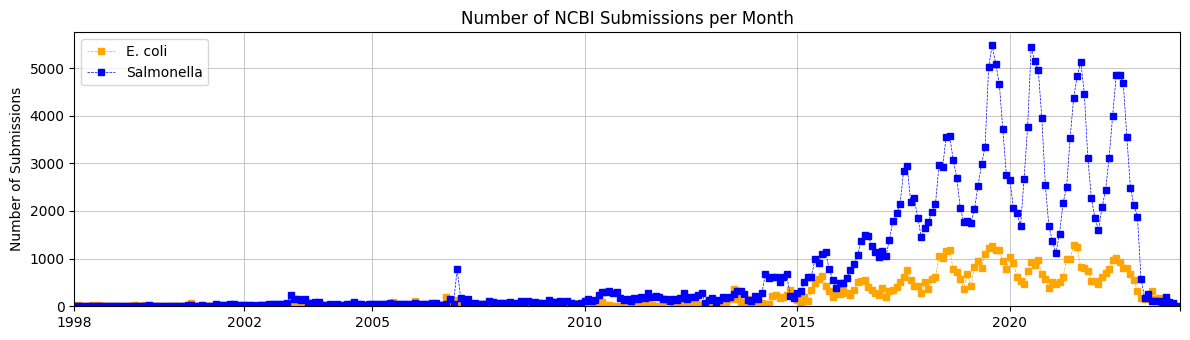

In [ ]:
#make a line plot of the value_counts of year_and_month. Put both dataframes on the same plot
year_month_counts1 = year_month_counts1[year_month_counts1.index.str[:4].astype(int) >= 1998]
year_month_counts2 = year_month_counts2[year_month_counts2.index.str[:4].astype(int) >= 1998]
plt.figure(figsize=(12, 3.5))
year_month_counts1.plot(kind='line', marker='o', label='E. coli', color='orange', linestyle='--', markersize=4, linewidth=0.5)
year_month_counts2.plot(kind='line', marker='s', label='Salmonella', color='blue', linestyle='--', markersize=4, linewidth=0.5)
plt.title('Number of NCBI Submissions per Month')
plt.ylabel('Number of Submissions')
#erase the x-axis label
plt.xlabel('')
#labels have no -01 in them
#plt.xticks(ticks=range(0, len(year_month_counts1), 12), labels=year_month_counts1.index[::12].str.replace('-01', ''), rotation=45)
#only include the ticks of 1998, 2002, 2005, 2010, 2015, 2020
plt.xlim(left='1998', right='2023')
plt.ylim(bottom=0)
plt.xticks(ticks=[0, 12*4, 12*7, 12*12, 12*17, 12*22, 12*26], labels=['1998', '2002', '2005', '2010', '2015', '2020', ''])
#put a vertical red line through 2009
#plt.axvline(x=12*38, color='red', linestyle='-')
#place a box that reads "2009"
plt.legend()
plt.grid(linewidth=0.5)
plt.tight_layout()
plt.savefig('../outputs/from_1998_ncbi_526_590.tiff', dpi=400)
plt.show()